Trying to generate figure in paper comparing noise power spectra to mitchell and rhodes

- For now, do one site at a time, but eventually we will do all sites in one go.
- Also just compute psds in-notebook for now, but eventually we will load them from file.

For the figure, we want to compare the PSD and slopes of the PSD of:
- observations (gray)
- sampled AR(1) (red) 10-year timescale noise (blue)
- sampled firn-filtered white noise (cyan)
- sampled firn-filtered red noise (orange)

In [55]:
from methane_noise_forcing import io
from hydra import compose, initialize
from omegaconf import open_dict
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from astropy.timeseries import LombScargle
from methane_noise_forcing.naming import generate_noise_realization_name, generate_firn_smoothing_name
from methane_noise_forcing.core import sample_ensemble_series
from pathlib import Path
from methane_noise_forcing.core import FirnFilter
from tqdm import tqdm

In [56]:
with initialize(version_base=None, config_path="../configs"):  # configs with data paths
    cfg = compose(config_name="config", overrides=[
        "+noise=white_noise_ar1",
        "++noise.duration_timeseries=4750",
        "+firn_kernel=gamma_wais",])

# load observations and detrend

In [57]:
## site names
site_names = ["wdc05a", "wdc06a", "gisp2", "neem"]

## import data and power spectra
data = {}
power_spectra_obs = {}
for site in site_names:
    data[site] = io.load_observational_data(site, **cfg.io[site].input)
    # convert to data array
    data[site] = xr.DataArray(
        data[site].ch4,
        dims=["time"],
        coords={"time": data[site].gas_age}
    )
    data[site] = data[site].rename("ch4").to_dataset()

    # detrend
    polyfit_results = data[site].ch4.polyfit(dim='time', deg=1)
    data[site]["ch4_detrended"] = data[site].ch4 - (polyfit_results["polyfit_coefficients"][0] * data[site].time + polyfit_results["polyfit_coefficients"][1])

    power_spectra_obs[site] = xr.open_dataset(cfg.io[site].power_spectra_path)

2025-08-11 19:38:19,446 - methane_noise_forcing.io - INFO - Loading WDC05A data from /Users/ericm/Documents/Research/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc05a.csv
2025-08-11 19:38:19,474 - methane_noise_forcing.io - INFO - Loading WDC06A data from /Users/ericm/Documents/Research/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2025-08-11 19:38:19,492 - methane_noise_forcing.io - INFO - Loading GISP2 data from /Users/ericm/Documents/Research/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_gisp2.csv
2025-08-11 19:38:19,505 - methane_noise_forcing.io - INFO - Loading NEEM data from /Users/ericm/Documents/Research/methane_noise_forcing/data/observations/cultivated/rhodesandbrook2019_neem.tab


# load white noise and AR(1) noise
Generates sampled firn-filtered AR(1) noise

In [58]:
## choose ONE site to work with
site = "wdc06a"  
with open_dict(cfg):
    cfg.sites = [site]
    cfg.sampling.site = site

In [59]:
## resolve path decorators
noise_name = generate_noise_realization_name(cfg)
firn_name = generate_firn_smoothing_name(cfg)

## raw noise realizations
input_dir = Path(cfg.paths.noise_realizations_root) / noise_name
noise = xr.open_dataset(input_dir / f"{noise_name}.nc")

## smoothed noise realizations
noise_smoothed = xr.open_dataset(input_dir / firn_name / f"smoothed_{noise_name}.nc")

# sample smoothed and non-smoothed AR(1) forcing
Generates sampled filtered and non-filtered AR(1) noise

In [60]:
## smoothed
noise_smoothed_sampled = sample_ensemble_series(
    da=noise_smoothed["ch4"],
    core_time=data[site].time,
    core_offset_flag="start",
    series_offset=150
)
# turn into dataset
noise_smoothed_sampled = noise_smoothed_sampled.to_dataset(name="red_smoothed")

## non-smoothed
noise_sampled = sample_ensemble_series(
    da=noise["ch4"],
    core_time=data[site].time,
    core_offset_flag="start",
    series_offset=150
)
# turn into dataset
noise_sampled = noise_sampled.to_dataset(name="red")

# smooth, sample, and scale white noise forcing
Treating raw white noise forcing as null hypothesis for why firn air sampling itself is not sufficient to explain the observed power spectrum.
Generates sampled filtered white noise

In [61]:
## generate smoothing filter
firn_filter = FirnFilter.fit_from_config(cfg.firn_kernel.type, cfg.firn_kernel.parameters)

## smooth noise forcing
white_noise_smoothed = []
for idx_ens in noise.ensemble.values:
    white_noise_smoothed.append(
        firn_filter.apply(noise['forcing'].sel(ensemble=idx_ens), dt_series=cfg.noise.dt)
    )
white_noise_smoothed = np.array(white_noise_smoothed)
# turn into xarray DataArray
white_noise_smoothed = xr.DataArray(
    white_noise_smoothed,
    dims=('ensemble', 'time'),
    coords={'ensemble': noise['ensemble'], 'time': noise['time']},
    attrs=noise['forcing'].attrs
)

## sample noise forcing and scale variance
white_noise_smoothed_sampled = sample_ensemble_series(
    da=white_noise_smoothed,
    core_time=data[site].time,
    core_offset_flag="start",
    series_offset=150
)
noise_sampled["white_smoothed"] = white_noise_smoothed_sampled

# scale variance of sampled noise to match observations

In [62]:
def scale_variance(da, target_std):
    """
    Scale the variance of a DataArray to match a target standard deviation.
    """
    current_std = da.std(dim='time')
    scaling_factor = target_std / current_std
    return da * scaling_factor

target_std = data[site]["ch4_detrended"].std()
noise_sampled["white_smoothed"] = scale_variance(noise_sampled["white_smoothed"], target_std)
noise_sampled["red"] = scale_variance(noise_sampled["red"], target_std)
noise_sampled["red_smoothed"] = scale_variance(noise_smoothed_sampled["red_smoothed"], target_std)

# calculate power spectra

In [63]:
def _calculate_power_spectrum(gas_age: np.ndarray, ch4: np.ndarray):
    """
    Use astropy's LombScargle to calculate the power spectrum.

    Parameters
    ----------
    gas_age : np.ndarray
        Array of gas ages.
    ch4 : np.ndarray
        Array of CH4 concentrations.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        Frequencies and power spectrum.
    """
    frequencies, power_spectrum = LombScargle(gas_age, ch4).autopower(
        normalization="psd", samples_per_peak=1
    )
    return frequencies, power_spectrum

## calculate power spectra for all cases, then combine into one dataset
power_spectra_red_smoothed = []
power_spectra_white_smoothed = []
power_spectra_red = []

if site == "neem":
    # reduce ensemble size for neem to 100 to speed up calculations
    ensembles = noise_sampled.ensemble.values[:100]
else:
    ensembles = noise_sampled.ensemble.values
for idx_ens in tqdm(ensembles, desc="Calculating power spectra"):
    # red noise smoothed
    frequencies, power_spectrum = _calculate_power_spectrum(
        noise_sampled["red_smoothed"].time.values,
        noise_sampled["red_smoothed"].sel(ensemble=idx_ens).values
    )
    power_spectra_red_smoothed.append(power_spectrum)

    # white noise
    frequencies, power_spectrum = _calculate_power_spectrum(
        noise_sampled["white_smoothed"].time.values,
        noise_sampled["white_smoothed"].sel(ensemble=idx_ens).values
    )
    power_spectra_white_smoothed.append(power_spectrum)

    # red noise 
    frequencies, power_spectrum = _calculate_power_spectrum(
        noise_sampled["red"].time.values,
        noise_sampled["red"].sel(ensemble=idx_ens).values
    )
    power_spectra_red.append(power_spectrum)

# combine into datasets
power_spectra_noise = xr.Dataset({
    "red_smoothed": xr.DataArray(
        np.array(power_spectra_red_smoothed),
        dims=("ensemble", "frequency"),
        coords={
            "ensemble": ensembles,
            "frequency": frequencies
        },
        attrs={"description": "Power spectrum of red noise (smoothed)"}
    ),
    "white_smoothed": xr.DataArray(
        np.array(power_spectra_white_smoothed),
        dims=("ensemble", "frequency"),
        coords={
            "ensemble": ensembles,
            "frequency": frequencies
        },
        attrs={"description": "Power spectrum of white noise (smoothed)"}
    ),
    "red": xr.DataArray(
        np.array(power_spectra_red),
        dims=("ensemble", "frequency"),
        coords={
            "ensemble": ensembles,
            "frequency": frequencies
        },
        attrs={"description": "Power spectrum of red noise"}
    )
})

Calculating power spectra: 100%|██████████| 1000/1000 [00:05<00:00, 189.16it/s]


# plots / analysis

In [64]:
colors = {
    "red_smoothed": "tab:orange",
    "white_smoothed": "tab:cyan",
    "red": "tab:blue",
    "obs": "k"
}
labels = {
    "red_smoothed": "filtered AR(1) noise",
    "white_smoothed": "filtered white noise",
    "red": "AR(1) noise",
    "obs": "observed"
}
tick_labels = [10000, 1000, 100, 10]
if site == "neem":
    markersize = 1
else:
    markersize = 4

def calculate_mean_and_ci(da, ci=0.95):
    """
    Calculate the mean and confidence interval of a DataArray.

    Parameters
    ----------
    da : xr.DataArray
        Input data array.
    ci : float, optional
        Confidence interval (default is 0.95).

    Returns
    -------
    Tuple[xr.DataArray, xr.DataArray]
        Mean, lower and upper confidence intervals.
    """
    mean = da.mean(dim='ensemble')
    percentile_low = (1 - ci) / 2
    percentile_high = (1 + ci) / 2
    ci_low = da.quantile(percentile_low, dim='ensemble')
    ci_high = da.quantile(percentile_high, dim='ensemble')
    return mean, ci_low, ci_high

means = {}
ci_lows = {}
ci_highs = {}
for key in ["red_smoothed", "white_smoothed", "red"]:
    mean, ci_low, ci_high = calculate_mean_and_ci(power_spectra_noise[key])
    means[key] = mean
    ci_lows[key] = ci_low
    ci_highs[key] = ci_high

Text(0, 0.5, 'CH$_4$ concentration (ppb)')

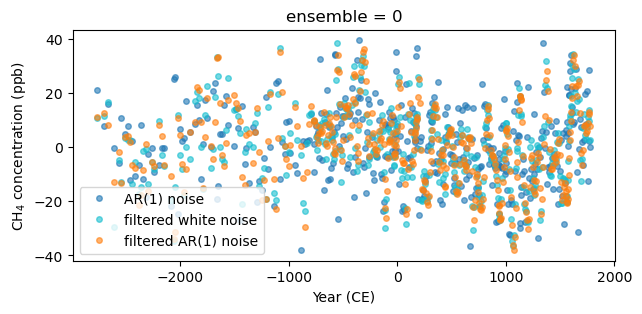

In [65]:
## quick and dirty view of the sampled noise
fig, ax = plt.subplots(figsize=(7, 3))
for key in noise_sampled.data_vars:
    noise_sampled[key].isel(ensemble=0).plot(ax=ax,
        marker='o', linestyle='', label=labels.get(key, key), color=colors.get(key, 'k'),
        markersize=markersize, alpha=0.6)

ax.legend()
ax.set_xlabel("Year (CE)")
ax.set_ylabel("CH$_4$ concentration (ppb)")

[Text(10000, 0, '10000'),
 Text(1000, 0, '1000'),
 Text(100, 0, '100'),
 Text(10, 0, '10')]

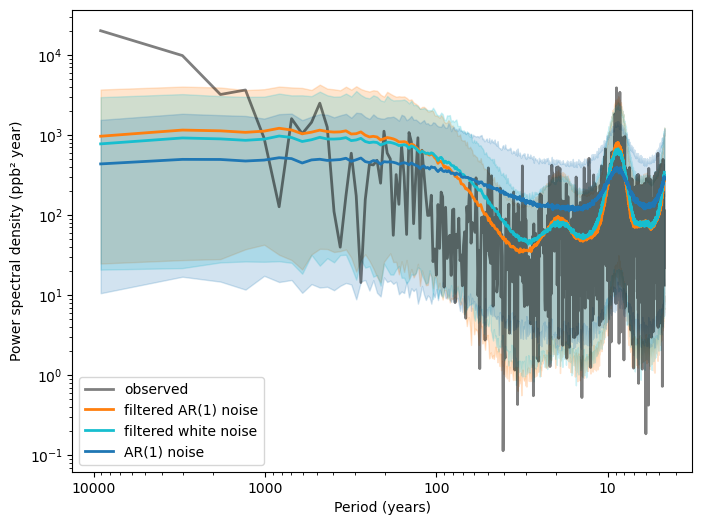

In [66]:
## plot power spectra
# optional lower bound mask
period_low = 0 # years
mask_obs = 1 / power_spectra_obs[site].frequency >= period_low
mask_noise = 1 / power_spectra_noise.frequency >= period_low

fig, ax = plt.subplots(figsize=(8, 6))
# observed power spectrum
ax.plot(1 / power_spectra_obs[site].where(mask_obs).frequency, 
        power_spectra_obs[site].where(mask_obs).power_spectrum_detrended_unnormalized,
        label=labels["obs"], color=colors["obs"], linestyle='-', linewidth=2, alpha=0.5)
# plot mean and confidence intervals for sampled noise
for key in ["red_smoothed", "white_smoothed", "red"]:
    ax.plot(1 / power_spectra_noise.where(mask_noise).frequency, means[key].where(mask_noise),
            label=labels[key], color=colors[key], linestyle='-', linewidth=2)
    ax.fill_between(1 / power_spectra_noise.where(mask_noise).frequency, ci_lows[key].where(mask_noise), ci_highs[key].where(mask_noise),
                    color=colors[key], alpha=0.2)

# plot params
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.legend()
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power spectral density (ppb² year)")
ax.set_xticks(tick_labels)
ax.set_xticklabels([f"{tick}" for tick in tick_labels])

The peaks in the high frequency range of the NEEM power spectrum along with the 10 and 20 year peaks in WAIS (wdc05a and wdc06a) are due to the sampling window. The 20 year peak arises only in the filtered timeseries because the power is suppressed, which lets it peak through.

It also looks like from the above plots that most of the heavy lifting is actually from the firn filter, not necessarily anything done with the AR(1) noise.

Below, I show the effects of the sampling window, firn transfer function, and red noise transfer function on the power spectrum of the sampled noise.

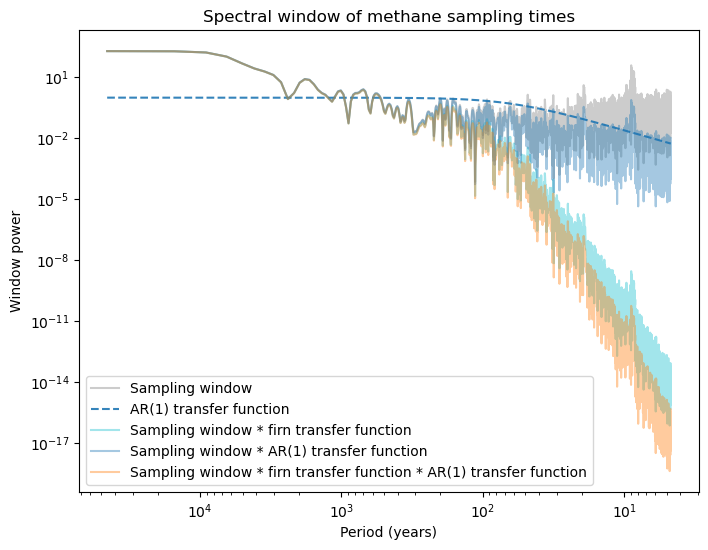

In [67]:
# Spectral window W(f)
t = data[site].time.values
y = np.ones_like(t)
ls = LombScargle(t, np.ones_like(t),
                     fit_mean=False, center_data=False,
                     normalization="psd")
freq_w, W = ls.autopower()
period_w = 1 / freq_w

## Firn transfer |H(f)|²
kernel = firn_filter.kernel                      # 1-D array, already normalised ∫G dτ = 1
dt_kernel = cfg.noise.dt                         # yrs
freq_h = np.fft.rfftfreq(kernel.size, d=dt_kernel)
H2 = np.abs(np.fft.rfft(kernel))**2
H2 /= H2[0]                                      # normalise

# Interpolate H2 to match freq_w
H2_interp = np.interp(freq_w, freq_h, H2, left=np.nan, right=np.nan)

# Combined response of firn and sampling window 
firn_window_combo = H2_interp * W

## AR(1) continuous transfer function
tau = cfg.noise.tau_ch4
S = 1 / (1 + (2 * np.pi * freq_w * tau)**2)  # AR(1) transfer function
S /= S[0]  # normalize

# combined response of AR(1) and sampling window
ar1_window_combo = S * W

# combined response of AR(1), firn transfer function, and sampling window
firn_window_ar1_combo = S * H2_interp * W

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(period_w, W, label="Sampling window", alpha=0.2, color=colors["obs"])
ax.loglog(period_w, S, label="AR(1) transfer function", linestyle='--', alpha=0.9, color=colors["red"])
ax.loglog(period_w, firn_window_combo, label="Sampling window * firn transfer function", alpha=0.4, color=colors["white_smoothed"])
ax.loglog(period_w, ar1_window_combo, label="Sampling window * AR(1) transfer function", alpha=0.4, color=colors["red"])
ax.loglog(period_w, firn_window_ar1_combo, label="Sampling window * firn transfer function * AR(1) transfer function", alpha=0.4, color=colors["red_smoothed"])
ax.set_xlabel("Period (years)")
# ax.set_xlim((5, None))
ax.set_ylabel("Window power")
ax.invert_xaxis()              # match your PSD plots
ax.set_title("Spectral window of methane sampling times")
ax.legend()
plt.show()

From the above, the transfer function rolls off at around 100 years. Therefore, the distinguishing feature between the firn filter and white noise and the firn filter and AR(1) noise is the slope between ~30 and 100 years, depending on the site.

Calculating power spectra of white noise: 100%|██████████| 1000/1000 [00:10<00:00, 98.27it/s]


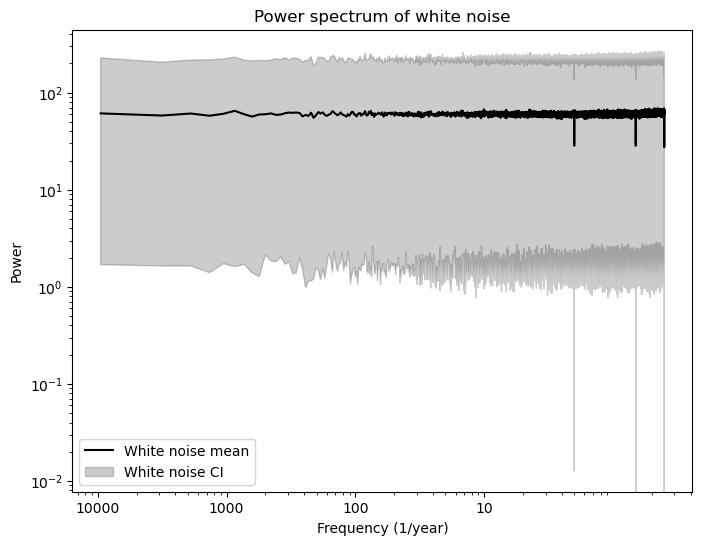

In [68]:
## plot power spectrum of white noise itself to ensure it is white noise
power_spectra_white_noise = {}
for idx_ens in tqdm(noise.ensemble.values, desc="Calculating power spectra of white noise"):
    frequencies, power_spectrum = _calculate_power_spectrum(
        noise["forcing"].time.values,
        noise["forcing"].sel(ensemble=idx_ens).values
    )
    power_spectra_white_noise[idx_ens] = xr.DataArray(
        power_spectrum,
        dims=("frequency",),
        coords={"frequency": frequencies}
    )
power_spectra_white_noise = xr.concat(
    list(power_spectra_white_noise.values()),
    dim="ensemble"
)

fig, ax = plt.subplots(figsize=(8, 6))
mean_white_noise, ci_low_white_noise, ci_high_white_noise = calculate_mean_and_ci(power_spectra_white_noise)
ax.loglog(mean_white_noise.frequency, mean_white_noise, label="White noise mean", color="k")
ax.fill_between(mean_white_noise.frequency, ci_low_white_noise, ci_high_white_noise,
                color="k", alpha=0.2, label="White noise CI")
ax.set_xlabel("Frequency (1/year)")
ax.set_ylabel("Power")
ax.set_title("Power spectrum of white noise")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks([1/period for period in tick_labels])
ax.set_xticklabels(tick_labels)
ax.legend()